# Geopolitical Risk, Inflation and Crude Oil Prices

This notebook looks at how crude oil prices have changed over time. I compare the oil price data with geopolitical risk data and US inflation data from the World Bank API.

To run the notebook:

1. Keep the original data files in the `DataP/` folder.
2. Run the notebook from top to bottom.
3. The cleaned data and results are saved in the `DataP_modified/` folder, which is created after running the notebook.

## Introduction

Oil prices can change for many reasons. Some changes are linked to supply and demand, while others may be linked to political events, conflicts or uncertainty around important transport routes such as the Strait of Hormuz or the Suez canal. 

In this project, I use historical crude oil price data together with the Geopolitical Risk Index and US inflation data. The inflation data is collected from the World Bank API.

The main question is:

**How have crude oil prices changed over time, and how are these changes related to geopolitical risk and US inflation?**

The project looks for patterns in the data. It does not try to prove that one variable directly causes changes in another.

### AI usage
In this project i used ChatGpt 5.5 for assisting with the following tasks;

- Assisted with the creating the Data pipeline chart

- Helped with creating code for calculating the monthly averages when transforming the data to yearly.

- Helped with making sure all the visualization code was written correctly and that everything was included.

- Helped with using and creating the code for the API calls. 

- Helped explaning when an "error code" was not easy to understand.

- Text and spell checking.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import os

# Create the folders for the output material
os.makedirs("DataP_modified", exist_ok=True)
os.makedirs("images", exist_ok=True)

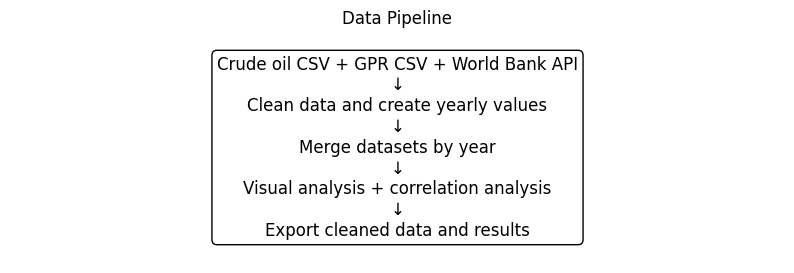

In [21]:
# Create the data pipeline diagram
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

text = (
    "Crude oil CSV + GPR CSV + World Bank API\n"
    "↓\n"
    "Clean data and create yearly values\n"
    "↓\n"
    "Merge datasets by year\n"
    "↓\n"
    "Visual analysis + correlation analysis\n"
    "↓\n"
    "Export cleaned data and results"
)

ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round", edgecolor="black", facecolor="white"))

plt.title("Data Pipeline")
plt.savefig("images/data_pipeline.png", bbox_inches="tight", dpi=150)
plt.show()

### Crude oil price data
#### The crude oil price dataset was downloaded from Kaggle, Link: https://ww.kaggle.com/datasets/sc231997/crude-oil-price

In [3]:
oil_raw = pd.read_csv("DataP/crude-oil-price.csv")

display(oil_raw.head(5))
# (In this project i chose to allways display 5 rows of information when visualizing the results)
print("Rows and columns:", oil_raw.shape)
print("Column names:")
print(oil_raw.columns)

,date,price,percentChange,change
0,1983-03-01 00:00:00+00:00,29.27,NaN,NaN
1,1983-04-01 00:00:00+00:00,30.63,4.646,1.36
2,1983-05-01 00:00:00+00:00,30.25,-1.241,-0.38
3,1983-06-01 00:00:00+00:00,31.38,3.736,1.13
4,1983-07-01 00:00:00+00:00,32.00,1.976,0.62


Rows and columns: (519, 4)
Column names:
Index(['date', 'price', 'percentChange', 'change'], dtype='str')


#### The oil price data is monthly. The date column is converted to datetime format, a year column is created, and yearly average oil prices are calculated.

In [4]:
oil_clean = oil_raw.copy()

oil_clean["date"] = pd.to_datetime(oil_clean["date"])
oil_clean["year"] = oil_clean["date"].dt.year

oil_yearly = (
    oil_clean
    .dropna(subset=["price"])
    .groupby("year", as_index=False)["price"]
    .mean()
    .rename(columns={"price": "average_oil_price"})
)

display(oil_yearly.head(5))
print("Rows and columns:", oil_yearly.shape)

,year,average_oil_price
0,1983,30.468000
1,1984,29.240833
2,1985,27.873333
3,1986,14.413333
4,1987,19.036667


Rows and columns: (44, 2)


In [5]:
oil_yearly.to_csv("DataP_modified/oil_yearly.csv", index=False)
# I am saving all the modified data in this project to a different folder, to keep everything more organised and I do not want to change the original data!

### Geopolitical risk data
#### The Geopolitical Risk Index dataset (GPR) contains monthly values for geopolitical risk. Link: https://www.policyuncertainty.com/gpr.html

In [6]:
gpr_raw = pd.read_csv("DataP/data_gpr_export.csv")

display(gpr_raw.head(5))
print("Rows and columns:", gpr_raw.shape)
print("Column names:")
print(gpr_raw.columns)

,month,GPR,GPRT,GPRA,GPRH,GPRHT,GPRHA,SHARE_GPR,N10,SHARE_GPRH,...,GPRHC_TUN,GPRHC_TUR,GPRHC_TWN,GPRHC_UKR,GPRHC_USA,GPRHC_VEN,GPRHC_VNM,GPRHC_ZAF,var_name,var_label
0,1900-01-01,NaN,NaN,NaN,87.927849,64.717491,110.453522,NaN,NaN,3.171932,...,0.0,0.038840,0.0,0.0,2.718799,0.051787,0.012947,1.152253,month,Date (year/month)
1,1900-02-01,NaN,NaN,NaN,86.566490,71.936844,96.250488,NaN,NaN,3.122822,...,0.0,0.125471,0.0,0.0,2.732469,0.027882,0.000000,1.143176,GPR,Recent GPR (Index: 1985:2019=100)
2,1900-03-01,NaN,NaN,NaN,72.140701,57.475853,84.499428,NaN,NaN,2.602422,...,0.0,0.180366,0.0,0.0,2.151507,0.025767,0.000000,0.863180,GPRT,Recent GPR Threats (Index: 1985:2019=100)
3,1900-04-01,NaN,NaN,NaN,54.419449,37.326603,65.858208,NaN,NaN,1.963141,...,0.0,0.066774,0.0,0.0,1.776175,0.000000,0.000000,0.641026,GPRA,Recent GPR Acts (Index: 1985:2019=100)
4,1900-05-01,NaN,NaN,NaN,64.405197,48.200008,74.373955,NaN,NaN,2.323370,...,0.0,0.081522,0.0,0.0,1.970109,0.013587,0.000000,0.788043,GPRH,Historical GPR (Index: 1900:2019=100)


Rows and columns: (1516, 115)
Column names:
Index(['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR',
       'N10', 'SHARE_GPRH',
       ...
       'GPRHC_TUN', 'GPRHC_TUR', 'GPRHC_TWN', 'GPRHC_UKR', 'GPRHC_USA',
       'GPRHC_VEN', 'GPRHC_VNM', 'GPRHC_ZAF', 'var_name', 'var_label'],
      dtype='str', length=115)


#### The GPR data is also monthly. The month column is converted to datetime format, a year column is created, and yearly average geopolitical risk is calculated.

In [7]:
gpr_clean = gpr_raw[["month", "GPR"]].copy()

gpr_clean["month"] = pd.to_datetime(gpr_clean["month"])
gpr_clean["year"] = gpr_clean["month"].dt.year

gpr_yearly = (
    gpr_clean
    .dropna(subset=["GPR"])
    .groupby("year", as_index=False)["GPR"]
    .mean()
    .rename(columns={"GPR": "average_geopolitical_risk"})
)

display(gpr_yearly.head(5))
print("Rows and columns:", gpr_yearly.shape)

,year,average_geopolitical_risk
0,1985,108.367792
1,1986,108.854954
2,1987,101.711436
3,1988,88.218414
4,1989,91.654269


Rows and columns: (42, 2)


In [22]:
# Export the data to DataP_modified
gpr_yearly.to_csv("DataP_modified/gpr_yearly.csv", index=False)

### US Inflation data

Here i connect to the world Bank API to collect yearly US inflation data. The API returns JSON data, which I then convert into pandas DataFrame. I first tried  using "Data from the whole world", but it had too many missing values, so I switched to US Data. This Data is more of a supplementary macroeconomic indicator to my research question.

In [23]:
# Get the data from the API
api_url = "https://api.worldbank.org/v2/country/USA/indicator/FP.CPI.TOTL.ZG?format=json&per_page=100"
response = requests.get(api_url)
data = response.json()

# Transform to dataframe
inflation_raw = pd.DataFrame(data[1])

# Clean the data (rename columns, change data types, remove empty values)
inflation_data = inflation_raw[["date", "value"]].copy()

inflation_data = inflation_data.rename(columns={
    "date": "year",
    "value": "us_inflation_rate"
})

inflation_data["year"] = inflation_data["year"].astype(int)
inflation_data["us_inflation_rate"] = pd.to_numeric(
    inflation_data["us_inflation_rate"],
    errors="coerce"
)

inflation_data = inflation_data.dropna(subset=["us_inflation_rate"])
inflation_data = inflation_data.sort_values("year")

display(inflation_data.head())
display(inflation_data.tail())
print("Rows and columns:", inflation_data.shape)

,year,us_inflation_rate
65,1960,1.457976
64,1961,1.070724
63,1962,1.198773
62,1963,1.239669
61,1964,1.278912


,year,us_inflation_rate
5,2020,1.233584
4,2021,4.697859
3,2022,8.002800
2,2023,4.116338
1,2024,2.949525


Rows and columns: (65, 2)


### Merging the datasets

The oil price data, geopolitical risk data and US inflation data are merged by year. Yearly data is used because the inflation data from the World Bank API is in that format. 

(This project is not that advanced, otherwise I would have tried to find monthly data instead). Also the US Data starts from 1985, and thats the latest of the datasets, so thats the starting point for the merged data.

In [24]:
# Merge oil and geopolitical risk (gpr)

oil_gpr_merged = pd.merge(
    oil_yearly,
    gpr_yearly,
    on="year",
    how="inner"
)

# Add inflation

final_data = pd.merge(
    oil_gpr_merged,
    inflation_data,
    on="year",
    how="inner"
)

display(final_data.head(5))
display(final_data.tail(5))
print("Rows and columns:", final_data.shape)

,year,average_oil_price,average_geopolitical_risk,us_inflation_rate
0,1985,27.873333,108.367792,3.545644
1,1986,14.413333,108.854954,1.898048
2,1987,19.036667,101.711436,3.664563
3,1988,15.974167,88.218414,4.077741
4,1989,19.573333,91.654269,4.827003


,year,average_oil_price,average_geopolitical_risk,us_inflation_rate
35,2020,38.595833,77.293804,1.233584
36,2021,68.069167,82.070236,4.697859
37,2022,92.289167,157.583193,8.002800
38,2023,77.436667,121.711255,4.116338
39,2024,75.498625,134.452751,2.949525


Rows and columns: (40, 4)


#### The cleaned and merged dataset is exported.

In [11]:
final_data.to_csv("DataP_modified/final_merged_data.csv", index=False)

## Visual analysis

The following plots show how crude oil prices, geopolitical risk and US inflation have changed over time. Scatterplots are also used to compare oil prices with geopolitical risk and inflation. 


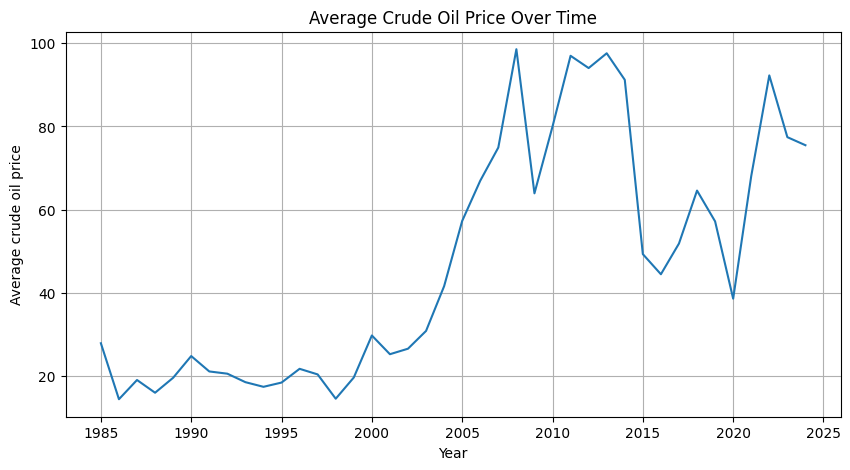

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(final_data["year"], final_data["average_oil_price"])
plt.title("Average Crude Oil Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average crude oil price")
plt.grid(True)
plt.show()

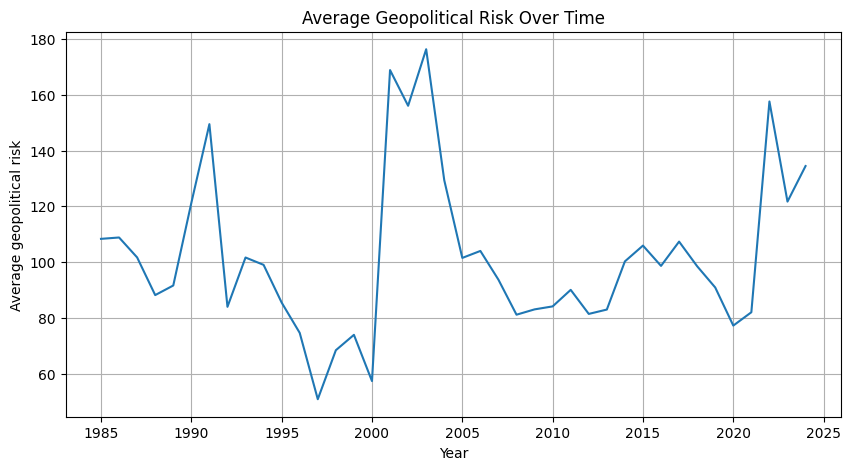

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(final_data["year"], final_data["average_geopolitical_risk"])
plt.title("Average Geopolitical Risk Over Time")
plt.xlabel("Year")
plt.ylabel("Average geopolitical risk")
plt.grid(True)
plt.show()

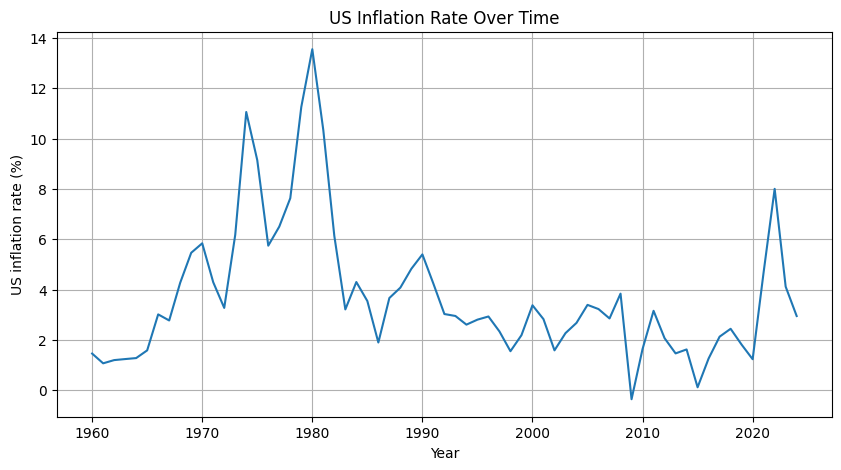

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(inflation_data["year"], inflation_data["us_inflation_rate"])

plt.title("US Inflation Rate Over Time")
plt.xlabel("Year")
plt.ylabel("US inflation rate (%)")
plt.grid(True)

plt.show()

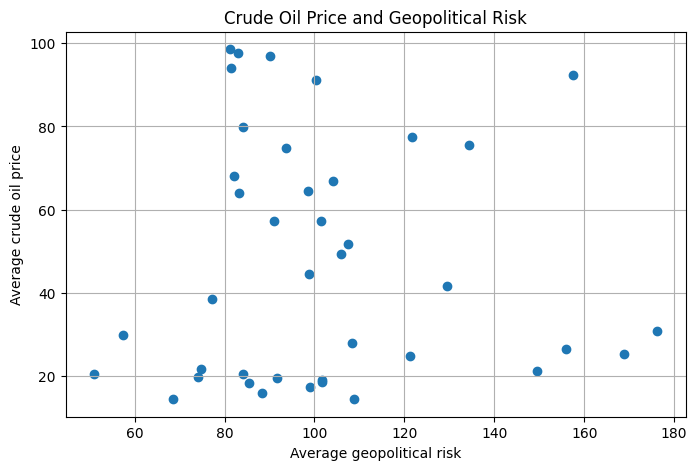

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(final_data["average_geopolitical_risk"], final_data["average_oil_price"])
plt.title("Crude Oil Price and Geopolitical Risk")
plt.xlabel("Average geopolitical risk")
plt.ylabel("Average crude oil price")
plt.grid(True)
plt.show()

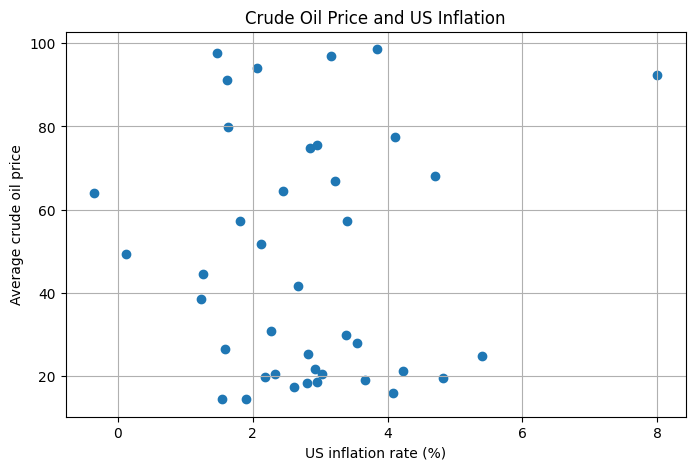

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(final_data["us_inflation_rate"], final_data["average_oil_price"])
plt.title("Crude Oil Price and US Inflation")
plt.xlabel("US inflation rate (%)")
plt.ylabel("Average crude oil price")
plt.grid(True)
plt.show()

### Interpretation of the visual analysis

The line plots show how crude oil prices, geopolitical risk and US inflation changed over time. The scatterplots are used to visually compare if there is a correlation between higher geopolitical risk and higher inflation with higher oil prices.

Based on the scatterplots, there does not seem to be a strong linear relationship between crude oil prices and geopolitical risk or between crude oil prices and US inflation. 

## Quantitative correlation analysis

We then use two quantitative methods to try to find correlation. First a correlation table, to examine whether crude oil prices, geopolitical risk and US inflation move together. Then the data is divided into high-GPR and low-GPR years to compare average oil prices between the two groups.

### Important to remember, these methods describe associations in the data, not causal effects!

In [25]:
# Create correlation table between all the parameters 
correlation_table = final_data[
    ["average_oil_price", "average_geopolitical_risk", "us_inflation_rate"]
].corr()

display(correlation_table)

,average_oil_price,average_geopolitical_risk,us_inflation_rate
average_oil_price,1.000000,-0.016811,0.023564
average_geopolitical_risk,-0.016811,1.000000,0.268336
us_inflation_rate,0.023564,0.268336,1.000000


In [26]:
# Analyze average oil price in high vs. low geopolitical risk years
gpr_median = final_data["average_geopolitical_risk"].median()

final_data["high_gpr_year"] = final_data["average_geopolitical_risk"] > gpr_median

oil_price_by_gpr = final_data.groupby("high_gpr_year", as_index=False)["average_oil_price"].mean()

oil_price_by_gpr["gpr_group"] = oil_price_by_gpr["high_gpr_year"].map({
    False: "Low GPR years",
    True: "High GPR years"
})

oil_price_by_gpr = oil_price_by_gpr[["gpr_group", "average_oil_price"]]

display(oil_price_by_gpr)

,gpr_group,average_oil_price
0,Low GPR years,50.753791
1,High GPR years,43.684473


The table shows that average oil prices were about 7 USD lower in high-GPR years than in low-GPR years. This is not a very large difference, and it does not suggest that oil prices were clearly higher during years with higher geopolitical risk.

#### The correlation table and the high-GPR comparison are exported.

In [19]:
correlation_table.to_csv("DataP_modified/correlation_table.csv")
oil_price_by_gpr.to_csv("DataP_modified/oil_price_by_gpr_group.csv", index=False)

### Conclusion

This project analyzed crude oil prices together with geopolitical risk and US inflation data. The crude oil price data and GPR data were monthly, while the World Bank inflation data was yearly. Therefore, the monthly oil price and GPR data were transformed into yearly averages before the datasets were merged by year.

The results show that crude oil prices changed substantially over time. However, the correlation between yearly average oil prices and geopolitical risk was weak in this dataset. When dividing the dataset into high and low geopolitcal risk groups and analyzing the average oil prices, we see that the difference was not substantial () The correlation between oil prices and US inflation was also weak.

The comparison between high-GPR and low-GPR years did not show higher average oil prices during high-GPR years. This does not necessarily mean that geopolitical events do not affect oil prices. One possible explanation is that yearly averages can cut out short term reactions to geopolitical events. Oil prices are also affected by many other factors, such as global demand, supply decisions, production levels and exchange rates.